In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from pprint import pprint

data_dir = '/Users/jcolen/Documents/chkd_toy_problem/data'

In [32]:
df = pd.read_csv(f'{data_dir}/all_fed_ref_monitor.csv')
zcta_df = gpd.read_file(f'{data_dir}/Hampton_Roads_ZCTA_Populations/Hampton_Roads_ZCTA_Populations.shp') \
    .rename({
        'Total Popu': 'Total Population',
        'Population': 'Population 0-19',
    }, axis=1) \
    .set_index('ZCTA5CE20')
zcta_df = zcta_df.to_crs('EPSG:4326')

air_quality = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))
air_quality.geometry = air_quality.geometry.set_crs('EPSG:4326')
air_quality['site_number'] = air_quality['site_number'].apply(lambda x: str(x).zfill(3))
air_quality['site_number'] = air_quality[['state_code', 'county_code', 'site_number']].apply(lambda row: '-'.join(row.values.astype(str)), axis=1)


air_quality['date_local'] = pd.to_datetime(air_quality['date_local']).dt.to_period('D')
air_quality = air_quality.loc[:, ['date_local', 'parameter', 'site_number', 'sample_measurement', 'geometry']]
air_quality = air_quality.dissolve(by=['date_local', 'parameter', 'site_number'], aggfunc='mean').reset_index()
air_quality

/var/folders/cl/t908rv_96mz1n31np3qj1n080000gp/T/ipykernel_94368/2041492639.py:1: DtypeWarning: Columns (17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{data_dir}/all_fed_ref_monitor.csv')


,date_local,parameter,site_number,geometry,sample_measurement
0,2018-01-01,Carbon monoxide,51-650-008,POINT (-76.38702 37.10373),0.233333
1,2018-01-01,Carbon monoxide,51-710-024,POINT (-76.30135 36.85555),NaN
2,2018-01-01,Nitrogen dioxide (NO2),51-650-008,POINT (-76.38702 37.10373),5.233333
3,2018-01-01,Nitrogen dioxide (NO2),51-710-024,POINT (-76.30135 36.85555),7.562500
4,2018-01-01,PM2.5 - Local Conditions,51-650-008,POINT (-76.38702 37.10373),5.237500
...,...,...,...,...,...
23332,2023-12-31,PM10 Total 0-10um STP,51-810-008,POINT (-76.18123 36.84188),11.612500
23333,2023-12-31,PM2.5 - Local Conditions,51-650-008,POINT (-76.38702 37.10373),3.945833
23334,2023-12-31,PM2.5 - Local Conditions,51-810-008,POINT (-76.18123 36.84188),8.462500
23335,2023-12-31,Sulfur dioxide,51-650-008,POINT (-76.38702 37.10373),1.054167


<Axes: >

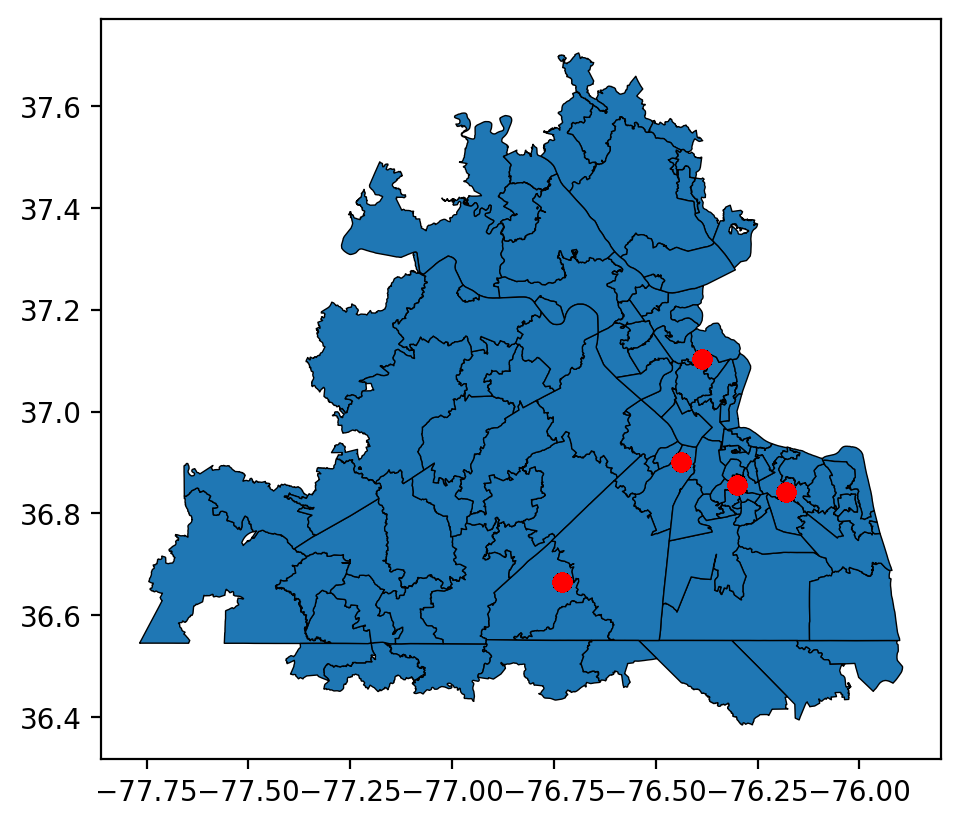

In [33]:
# Plot of Hampton Roads counties
fig, ax = plt.subplots(1, 1, dpi=200)
zcta_df.plot(ax=ax, edgecolor='black', linewidth=0.5)
air_quality.plot(ax=ax, color='red')

# Plot time-series of each measurement

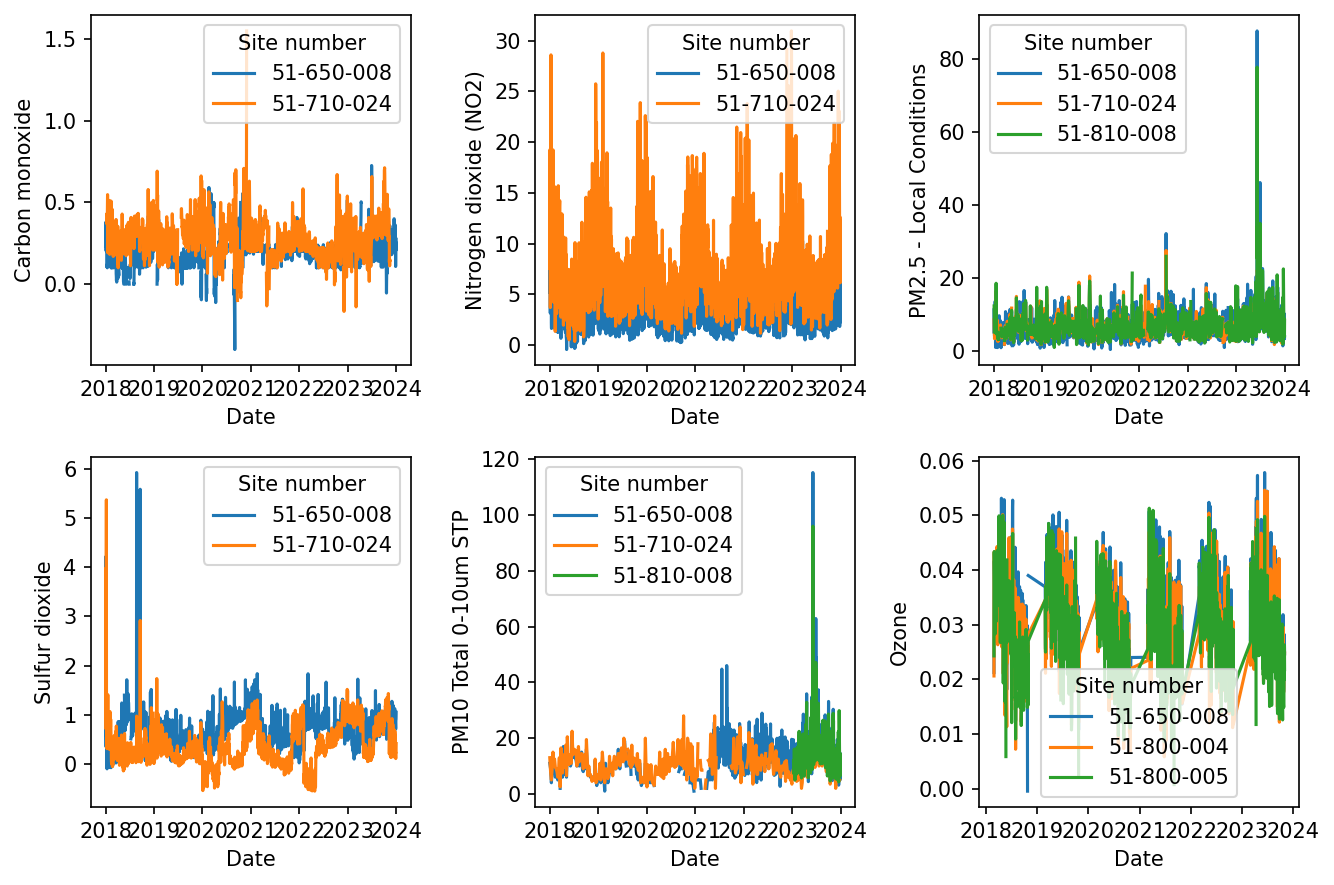

In [34]:
params = air_quality['parameter'].unique()
fig, ax = plt.subplots(2, 3, dpi=150, figsize=(9, 6))
ax = ax.flatten()

for i, param in enumerate(params):
    param_df = air_quality[air_quality['parameter'] == param]
    for site_number in param_df['site_number'].unique():
        sub_df = param_df[param_df['site_number'] == site_number]
        sub_df = sub_df.sort_values(by='date_local')
        ax[i].plot(sub_df['date_local'].dt.to_timestamp(), sub_df['sample_measurement'], label=site_number)
    ax[i].set(xlabel='Date', ylabel=param)
    ax[i].legend(title='Site number')

plt.tight_layout()

In [35]:
air_quality[
    (air_quality['date_local'].dt.year == 2023) &
    (air_quality['date_local'].dt.month == 6) &
    (air_quality['parameter'] == 'PM10 Total 0-10um STP')]

,date_local,parameter,site_number,geometry,sample_measurement
20639,2023-06-01,PM10 Total 0-10um STP,51-650-008,POINT (-76.38702 37.10373),15.283333
20640,2023-06-01,PM10 Total 0-10um STP,51-810-008,POINT (-76.18123 36.84188),13.491667
20652,2023-06-02,PM10 Total 0-10um STP,51-650-008,POINT (-76.38702 37.10373),9.845833
20653,2023-06-02,PM10 Total 0-10um STP,51-810-008,POINT (-76.18123 36.84188),8.741667
20666,2023-06-03,PM10 Total 0-10um STP,51-650-008,POINT (-76.38702 37.10373),15.425000
...,...,...,...,...,...
21016,2023-06-29,PM10 Total 0-10um STP,51-650-008,POINT (-76.38702 37.10373),62.854167
21017,2023-06-29,PM10 Total 0-10um STP,51-710-024,POINT (-76.30135 36.85555),37.500000
21018,2023-06-29,PM10 Total 0-10um STP,51-810-008,POINT (-76.18123 36.84188),47.141667
21031,2023-06-30,PM10 Total 0-10um STP,51-650-008,POINT (-76.38702 37.10373),46.604167


In [36]:
air_quality[
    (air_quality['date_local'].dt.year == 2023) &
    (air_quality['date_local'].dt.month == 6) &
    (air_quality['parameter'] == 'PM10 Total 0-10um STP') & 
    (air_quality['site_number'] == 24)]

,date_local,parameter,site_number,geometry,sample_measurement


# Spatial interpolation methods

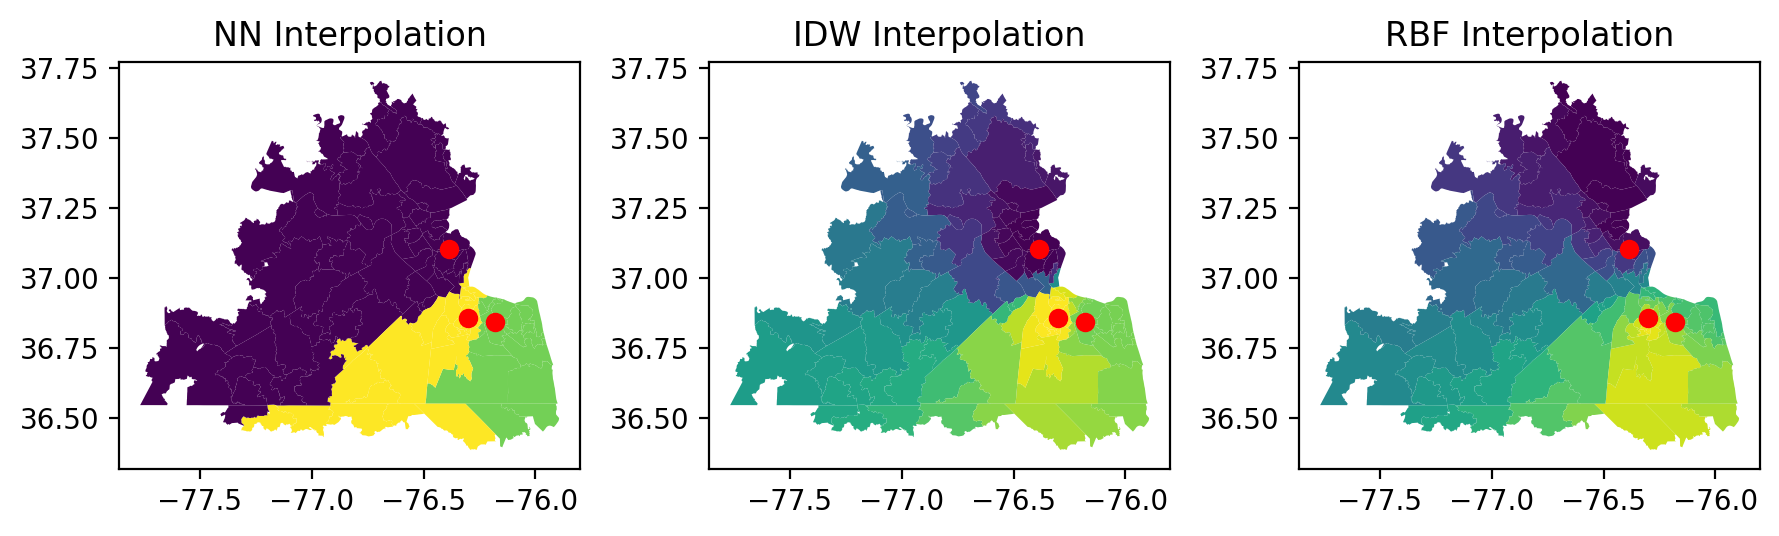

In [50]:
def idw_interpolate(data, regions, column='sample_measurement', p=5):
    assert data.crs == regions.crs

    # Target points
    centroids = regions.to_crs('+proj=cea').centroid.to_crs(regions.crs)
    centroids = np.array([(point.x, point.y) for point in centroids])

    # Determine measurement points in the data
    points = np.array([(point.x, point.y) for point in data.geometry])

    # Compute distance matrix between the two
    distance = np.linalg.norm(centroids[:, None] - points[None, :], axis=-1)

    # Compute IDW weights
    weights = np.power(distance, -p) # Define IDW weights
    weights /= weights.sum(axis=1, keepdims=True)

    # Perform interpolation
    interpolated = np.dot(weights, data[column])
    return interpolated

from scipy.interpolate import RBFInterpolator
def rbf_interpolate(data, regions, column='sample_measurement', kernel='linear'):
    assert data.crs == regions.crs

    # Target points 
    centroids = regions.to_crs('+proj=cea').centroid.to_crs(regions.crs)
    centroids = np.array([(point.x, point.y) for point in centroids])

    # Determine measurement points in the data
    points = np.array([(point.x, point.y) for point in data.geometry])

    # Perform RBF interpolation
    rbf = RBFInterpolator(points, data[column], kernel=kernel)
    interpolated = rbf(centroids)
    return interpolated


data = air_quality[
    (air_quality['date_local'].dt.year == 2021) &
    (air_quality['date_local'].dt.month == 7) &
    (air_quality['parameter'] == 'PM2.5 - Local Conditions')]

data = data.dissolve(by=['site_number'], aggfunc={'sample_measurement': 'mean'})

toplot = zcta_df.to_crs('+proj=cea').sjoin_nearest(data.to_crs('+proj=cea')).to_crs(zcta_df.crs) \
    .rename({'sample_measurement': 'nearest'}, axis=1)
toplot['idw'] = idw_interpolate(data, toplot)
toplot['rbf'] = rbf_interpolate(data, toplot)

fig, ax = plt.subplots(1, 3, dpi=200, figsize=(9, 3))
toplot.plot(ax=ax[0], column='nearest')
ax[0].set_title('NN Interpolation')
vmin, vmax = ax[0].collections[0].get_clim()

toplot.plot(ax=ax[1], column='idw', vmin=vmin, vmax=vmax)
ax[1].set_title('IDW Interpolation')

toplot.plot(ax=ax[2], column='rbf', vmin=vmin, vmax=vmax)
ax[2].set_title('RBF Interpolation')

for a in ax:
    data.plot(ax=a, color='red')

plt.tight_layout()

In [40]:
toplot.to_crs('+proj=cea').centroid

ZCTA5CE20
27818     POINT (-8573158.129 3774671.99)
27950    POINT (-8459680.986 3775893.323)
23128    POINT (-8508041.584 3858461.699)
23314    POINT (-8518314.572 3815507.009)
23462     POINT (-8477096.773 3804425.02)
                       ...               
23878    POINT (-8573895.176 3803755.485)
23668    POINT (-8497968.382 3820736.928)
23667    POINT (-8497138.304 3820796.228)
23681    POINT (-8503016.778 3827545.169)
23081    POINT (-8544657.162 3836503.957)
Length: 122, dtype: geometry